In [2]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

In [3]:

# Load Pantheon+ SN metadata
print("Loading Pantheon+ supernova data...")
df_pantheon = pd.read_csv(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat",
    "data/Pantheon+SH0ES.dat",
    sep=r"\s+"
)

print("Loading SN covariance matrix...")
n_sn = len(df_pantheon)

# Load .cov file with NumPy, skipping the first line (which contains just "1701")
cov_flat = np.loadtxt(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov",
    "data/Pantheon+SH0ES_STAT+SYS.cov",
    skiprows=1
)

# Reshape into square matrix
cov_matrix = cov_flat.reshape((n_sn, n_sn))

# Confirm shape is correct
assert cov_matrix.shape == (n_sn, n_sn), f"Expected ({n_sn},{n_sn}), got {cov_matrix.shape}"

# Invert covariance and pre-compute log-determinant for SN likelihood
global Cov_inv, logdetCov
Cov_inv = np.linalg.inv(cov_matrix)
sign, logdet = np.linalg.slogdet(cov_matrix)
if sign <= 0:
    raise ValueError("Covariance matrix is not positive-definite!")
logdetCov = logdet
print("Data loaded. Running joint cosmographic fits...")


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Data loaded. Running joint cosmographic fits...


In [23]:
df_agn = load_quasar_data("results/aug10_stonebwb_N20w2000s1000t6c4.h5", populate_sdss=False)

print(list(df_agn.keys()))


Reading quasars from HDF5: 100%|██████████| 189/189 [00:00<00:00, 213.38it/s]


Number of quasars loaded: 189
Length of colin_df: 189
Number with apparent_mag_2500 > 0: 189
Length of merged DataFrame: 189
object_id not in merged: []
Number of quasars with 0 < z <= 1.0: 33
Number of quasars with z > 3: 9
Highest redshift quasar: 4.15
Columns with NaNs: ['chi_sq_g', 'chi_sq_all']
Number of quasars with 0 < z <= 1.0: 32
Number of dropped quasars with 0 < z <= 1.0: 1
Number of quasars with z > 3: 8
Final number of quasars: 187
['object_id', 'EXTINCTION', 'FHOST_5100', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000', 'LOGL3000_ERR', 'LOGL5100', 'LOGL5100_ERR', 'LOGLBOL', 'M_i', 'alpha_host', 'alpha_host_err', 'bwb_alpha', 'bwb_alpha_err', 'bwb_beta', 'bwb_beta_err', 'clean_bands', 'dec', 'ebv', 'eta_A1', 'eta_A1_err', 'eta_A1_mean', 'eta_A1_mean_err', 'eta_A2', 'eta_A2_err', 'eta_A2_mean', 'eta_A2_mean_err', 'eta_break', 'eta_break_err', 'eta_tau1', 'eta_tau1_err', 'eta_tau1_mean', 'eta_tau1_mean_err', 'eta_tau2', 'eta_tau

In [24]:
import hubble_fit
cosmo_model = 'Flatw0waCDM'
sampler, flat_samples, labels, mag_corr, logZ, logZerr = hubble_fit.run_mcmc_pipeline(df_agn, df_pantheon, cosmo_model=cosmo_model,
                                                                                      completeness=True, use_full_cov=False,resume=True)


log tau UV RF mean:  2.759490072900297
log tau UV RF pivot:  2.764173754926386
log sigma0 mean:  -0.8456052038213319
log sigma0 pivot:  -0.8329037511443201
f_host pivot:  0.054245284123986534
f_host pivot:  nan
alpha_nu pivot:  -0.5
z mean: 1.683,  z_agn_pivot: 1.589


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:568: RuntimeWarning: invalid value encountered in multiply
  avg = avg_as_array = np.multiply(a, wgt,


Fraction of finite likelihoods: 1.0

Bayesian evidence logZ = 553.27 ± 0.40
Dynesty results stats:
  samples shape: (4634, 14)
  weights max: 0.00126088893311095
  effective samples: 1150.7914167136116
       gamma_sn: 0.0112 (+0.0113, -0.0099)
         tau_Ms: 0.0964 (+0.0652, -0.0599)
          M0_sn: -19.2455 (+0.0282, -0.0283)
         M0_agn: -22.9304 (+0.0669, -0.0619)
log_sigma0_break: -1.6125 (+1.0043, -0.9380)
     eta_A1_agn: 4.6742 (+0.3323, -0.3663)
     eta_A2_agn: 0.9571 (+5.8748, -6.4998)
  eta_break_agn: 5.1338 (+3.2423, -3.2848)
       beta_agn: -2.4391 (+0.2738, -0.2207)
          log_f: -1.2103 (+0.3733, -0.7669)
             H0: 72.8176 (+1.1205, -0.9712)
            Om0: 0.5218 (+0.0319, -0.0323)
             wp: -6.4297 (+2.2586, -2.6747)
             wa: -9.5328 (+4.2270, -4.8344)
             w0: -0.7425 (+0.3193, -0.2701)
             wa: -9.5328 (+4.2270, -4.8344)


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/dynesty/dynamicsampler.py:2046: RuntimeWarning: You tried to resume the run that has ended successfully.
This is not supported. No sampling was performed
  warnings.warn(


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dutra/dev/eztaox/qvc/hubble_plotting.py:554: UserWarning: This f

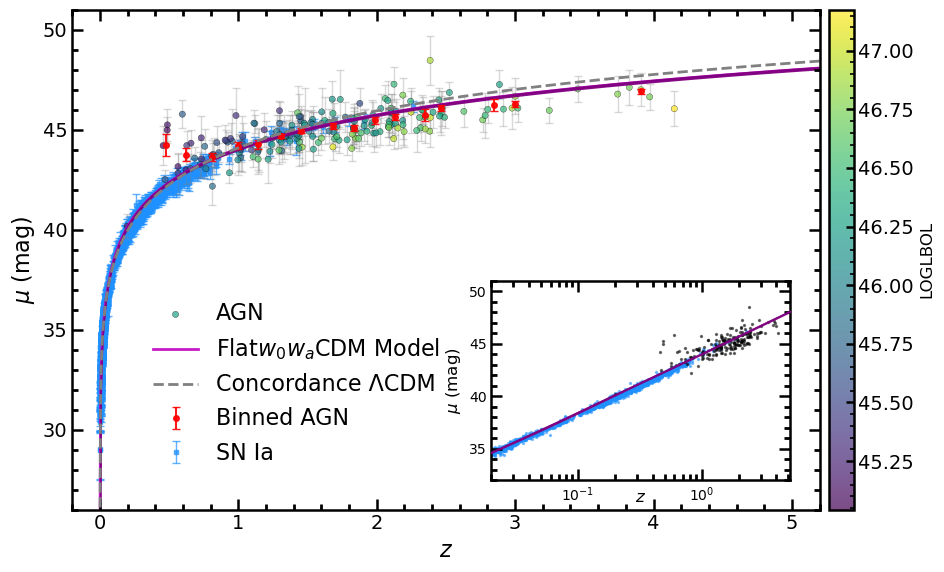

In [25]:
residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True, show_true=False)

In [22]:
df_agn[df_agn['z'] < 0.6][['z','object_id']].sort_values('z')

,z,object_id
66,0.197511,1388230
57,0.457000,1388047
41,0.471145,1387685
108,0.486454,1389212
132,0.488000,1389832
114,0.564000,1389395
74,0.564365,1388390
63,0.596000,1388129


In [19]:
df_agn[df_agn['alpha_lambda'] > 0][['object_id', 'sdss_name', 'alpha_lambda']]

,object_id,sdss_name,alpha_lambda
29,1387494,025229.25+001624.3,0.679556
31,1387513,025225.52+003405.7,0.006120
42,1387687,025156.19+001437.1,0.059409
52,1387917,025105.14-001732.1,0.428806
57,1388047,025042.90-004138.8,0.155037
63,1388129,025026.66+000903.4,0.394309
77,1388442,024929.19-002104.3,0.437421
83,1388576,024906.75+000823.6,0.275172
132,1389832,024538.29-004705.4,0.177316
147,1390159,024452.32-003317.8,0.060482


In [18]:
# Show the AGN entry with the greatest redshift (z)
df_agn.loc[df_agn['z'].idxmax()][['sdss_name', 'alpha_lambda']]

sdss_name       025204.28+003137.0
alpha_lambda              -0.03937
Name: 40, dtype: object

In [30]:
df_agn[(np.abs(residuals) > 2) ][['object_id', 'sdss_name', 'alpha_lambda', 'z', 'ra', 'dec', 'alpha_lambda']]

,object_id,sdss_name,alpha_lambda,z,ra,dec,alpha_lambda
57,1388047,025042.90-004138.8,0.155037,0.457000,42.678750,-0.694128,0.155037
63,1388129,025026.66+000903.4,0.394309,0.596000,42.611112,0.150947,0.394309
108,1389212,024712.90-011106.2,-0.993738,0.486454,41.803759,-1.185074,-0.993738
132,1389832,024538.29-004705.4,0.177316,0.488000,41.409558,-0.784846,0.177316
181,1391283,024154.42-004757.6,-4.137992,2.386000,40.476788,-0.799348,-4.137992


In [7]:
df_agn[df_agn['alpha_lambda'] < -4][['object_id', 'sdss_name', 'alpha_lambda']]

,object_id,sdss_name,alpha_lambda
129,1389763,024550.79-004328.2,-4.595771
168,1390677,024325.97-003145.2,-4.977811
183,1391283,024154.42-004757.6,-4.137992


In [9]:
df_agn_resid_gt2 = df_agn[np.abs(residuals) > 2]
df_agn_resid_gt2[['object_id', 'sdss_name', 'z', 'ra', 'dec']]

,object_id,sdss_name,z,ra,dec
58,1388047,025042.90-004138.8,0.457000,42.678750,-0.694128
64,1388129,025026.66+000903.4,0.596000,42.611112,0.150947
109,1389212,024712.90-011106.2,0.486454,41.803759,-1.185074
133,1389832,024538.29-004705.4,0.488000,41.409558,-0.784846
182,1391283,024154.42-004757.6,2.386000,40.476788,-0.799348


Reduced chi^2: 31.502


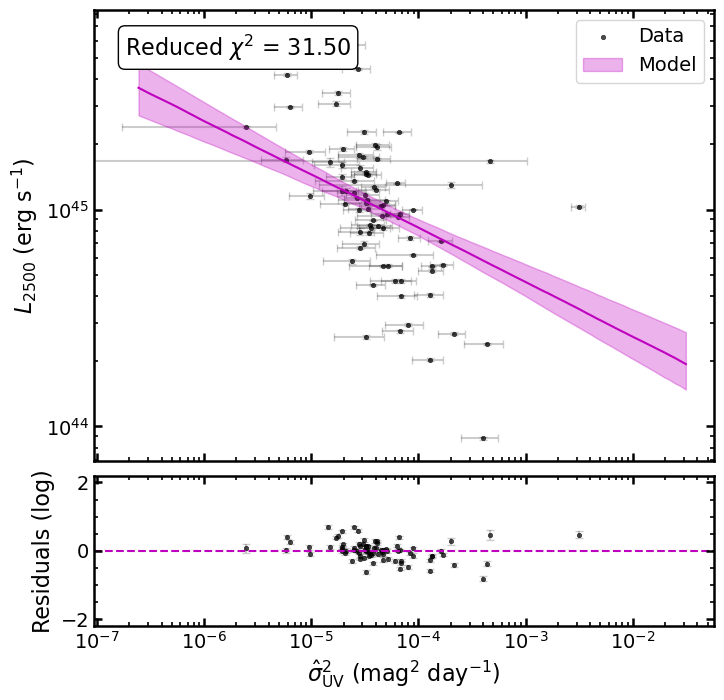

In [ ]:
from hubble_plotting import plot_predicted_L2500_vs_sigmahat

plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, cosmo_model, show=True)

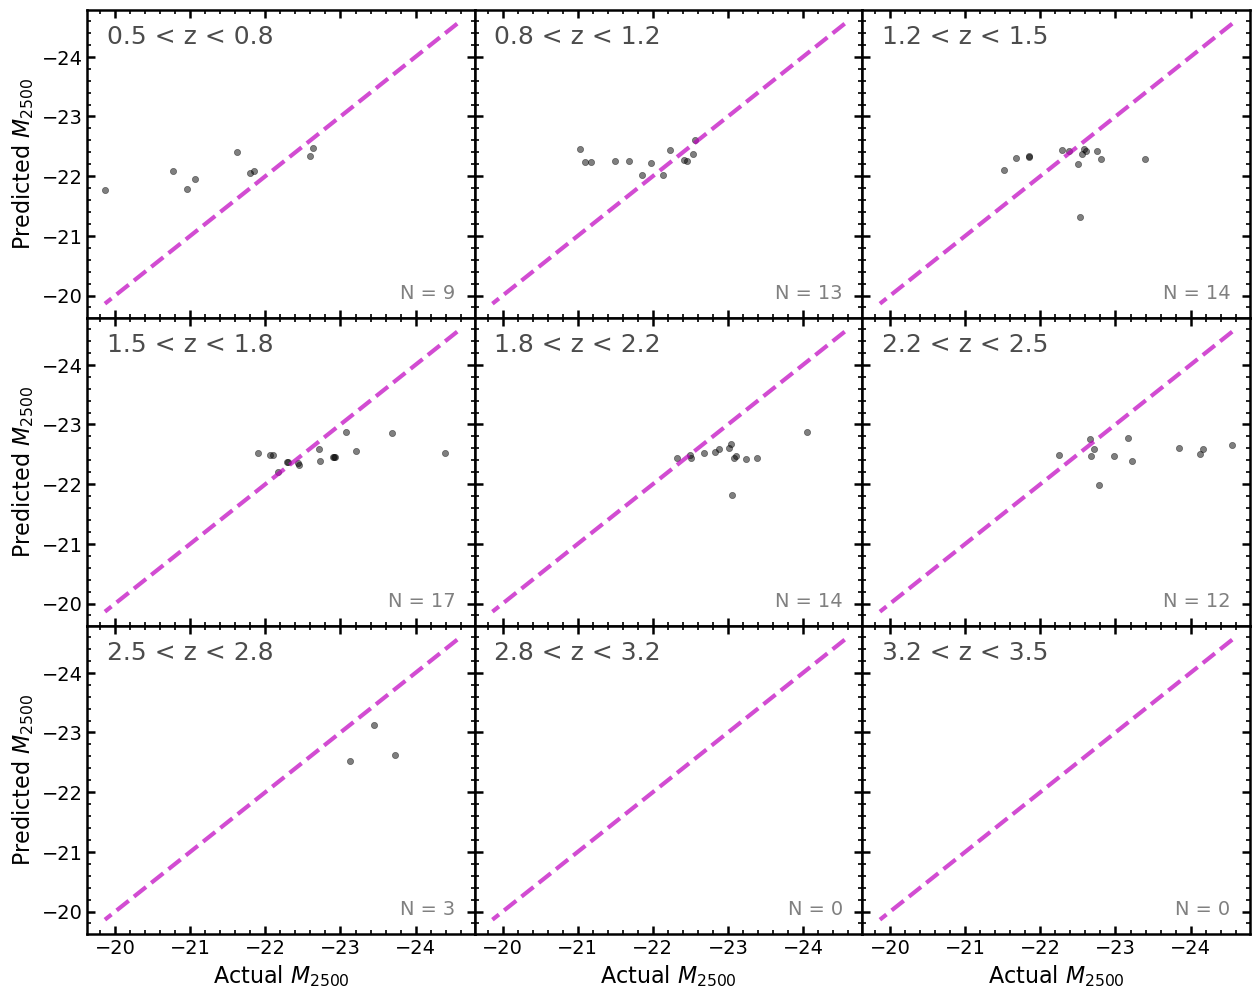

In [ ]:
from hubble_plotting import plot_predicted_vs_actual_M2500

plot_predicted_vs_actual_M2500(flat_samples, df_agn, cosmo_model, show=True)

Fitted parameters:
  x_break: -1.5000
  d1: 3.0000
  d2: -1.0000
  M0: -20.0000
  ds: 0.0188


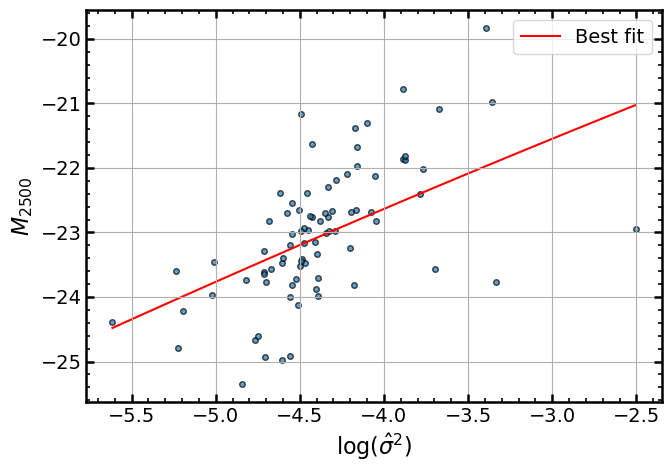

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt


def broken_power_law(x, x_break, d1, d2, M0, ds):
    """Broken power law defined to be zero at x_break.
    That decorrelates d1, d2 from M0_agn.
    """
    #print(f"broken_power_law: x={x}, x_break={x_break}, d1={d1}, d2={d2}, ds={ds}")
    delta = x - x_break
    term = (d2 - d1) / ds * np.log10(1 + 10**(ds * delta))
    offset = (d2 - d1) / ds * np.log10(2)  # value of the term when delta = 0
    return d1 * delta + term - offset + M0

d = df_agn[df_agn['LOGL2500'] > 0]  # Filter to only include objects with LOGL2500 < 0
initial_guess = [-1.1, 4, 0, -27, 2]
M_2500_actual = -2.5 * d['LOGL2500'] + 90

params, cov = curve_fit(
    broken_power_law,
    2*d['log_sigma_hat_UV'],
    M_2500_actual,
    p0=initial_guess,
    bounds=([-1.5, 3, -1, -30, 0], [-0.8, 6, 2, -20, 100])
)

print("Fitted parameters:")
for name, value in zip(['x_break', 'd1', 'd2', 'M0', 'ds'], params):
    print(f"  {name}: {value:.4f}")

x_fit = np.linspace((2*d['log_sigma_hat_UV']).min(), (2*d['log_sigma_hat_UV']).max(), 200)
y_fit = broken_power_law(x_fit, *params)

plt.figure(figsize=(7, 5))
plt.scatter(2*d['log_sigma_hat_UV'], M_2500_actual, alpha=0.7, edgecolor='k', zorder=-2)
plt.plot(x_fit, y_fit, color='red', label='Best fit', zorder=-1)

plt.legend()
plt.xlabel(r'$\log(\hat{\sigma}^2)$')
plt.ylabel(r'$M_{2500}$')
plt.grid(True)
plt.tight_layout()
plt.show()